# 02 — CDDF and dN/dX from the catalog

The **column density distribution function** (CDDF) and the **incidence
rate** dN/dX are the two principal *number-statistics* of HCDs.  Both
are derived from the per-absorber catalog you saw in notebook 01.

In this notebook you will:

1. Load the cached `cddf_corrected.npz` for one (sim, snap) and look at
   what it contains.
2. Recompute it from `catalog.npz` using
   `hcd_analysis.cddf.measure_cddf_from_dataframe`, and verify the
   recomputation matches the cache to within rounding.
3. Compute the per-class dN/dX (DLA, subDLA, LLS) and confirm against
   `hcd_summary_lf.h5`.
4. Reproduce a comparison plot against the Ho+21 CDDF measurement (a
   common sanity check; this is the figure-1 of much of the analysis
   work in this repo).


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

HCD_OUT_ROOT = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs')
SIM = 'ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'
SNAP = 22
SNAP_DIR = HCD_OUT_ROOT / SIM / f'snap_{SNAP:03d}'

with open(SNAP_DIR / 'meta.json') as f:
    meta = json.load(f)
print(f'sim={SIM[:50]}…  snap={SNAP}  z={meta["z"]}')


sim=ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.66…  snap=22  z=2.0


## 1. The cached CDDF

The pipeline writes two CDDF files:

* `cddf.npz` — the **original** (buggy) CDDF.  Do not use.
* `cddf_corrected.npz` — the corrected version after the absorption-path
  fix described in `docs/bugs_found.md` §7.

The bug was a missing factor of `(1+z)·h` in the absorption path
denominator.  The corrected file divides by an extra `(1+z)·h` to fix it
in-place (`patch_factor` is stored as an attribute).  Always use
`_corrected.npz` going forward; only touch `cddf.npz` if you are
auditing the bugfix itself.


In [2]:
cddf = np.load(SNAP_DIR / 'cddf_corrected.npz', allow_pickle=True)
print('Fields:')
for k in cddf.files:
    a = cddf[k]
    print(f'  {k:18s} shape={getattr(a, "shape", "()")} dtype={a.dtype}')
print()
print('z              :', float(cddf['z']))
print('n_sightlines   :', int(cddf['n_sightlines']))
print('dX_per_sightline:', float(cddf['dX_per_sightline']))
print('total_path     :', float(cddf['total_path']))
print('dx_bug_patched :', bool(cddf['dx_bug_patched']))
print('patch_factor   :', float(cddf['patch_factor']))


Fields:
  log_nhi_centres    shape=(30,) dtype=float64
  log_nhi_edges      shape=(31,) dtype=float64
  f_nhi              shape=(30,) dtype=float64
  n_absorbers        shape=(30,) dtype=int64
  dX_per_sightline   shape=() dtype=float64
  total_path         shape=() dtype=float64
  n_sightlines       shape=() dtype=int64
  z                  shape=() dtype=float64
  dx_bug_patched     shape=() dtype=bool
  patch_date         shape=() dtype=|S10
  patch_factor       shape=() dtype=float64

z              : 2.0
n_sightlines   : 691200
dX_per_sightline: 0.36024922281400423
total_path     : 249004.26280903973
dx_bug_patched : True
patch_factor   : 2.005


**Definition reminder.**  The CDDF is

```
f(N_HI) = d²n / (dN_HI dX)
```

where `n` is the count of absorbers and `dX` the absorption distance per
sightline.  In code this is:

```python
counts, edges = np.histogram(log_nhi, bins=log_nhi_edges)
dN     = 10**edges[1:] - 10**edges[:-1]    # cm⁻²
f_nhi  = counts / (dN * total_path)
```

Higher-NHI bins are exponentially harder to fill, so a CDDF plot is
always log-log.


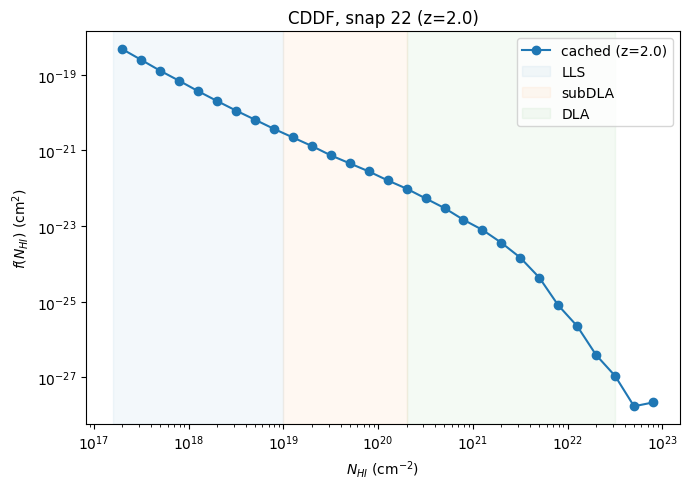

In [3]:
log_nhi_centres = cddf['log_nhi_centres']
f_nhi           = cddf['f_nhi']
n_abs           = cddf['n_absorbers']

mask = f_nhi > 0  # drop empty bins for the log plot

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(10**log_nhi_centres[mask], f_nhi[mask], 'o-', label=f'cached (z={meta["z"]})')
ax.set(xlabel=r'$N_{HI}$ (cm$^{-2}$)', ylabel=r'$f(N_{HI})$ (cm$^2$)',
       title=f'CDDF, snap {SNAP} (z={meta["z"]})')
ax.axvspan(10**17.2, 10**19.0, alpha=0.05, color='C0', label='LLS')
ax.axvspan(10**19.0, 10**20.3, alpha=0.05, color='C1', label='subDLA')
ax.axvspan(10**20.3, 10**22.5, alpha=0.05, color='C2', label='DLA')
ax.legend()
fig.tight_layout()
plt.show()


## 2. Recompute it from the catalog

The cached file is just the result of running `measure_cddf` on the
catalog.  Recomputing should reproduce it bitwise (modulo numpy
histogram tie-breaking on bin edges, which never matters here):


In [4]:
import pandas as pd
from hcd_analysis.cddf import measure_cddf_from_dataframe

# Build a minimal DataFrame the helper expects
arr_cat = np.load(SNAP_DIR / 'catalog.npz', allow_pickle=True)
df = pd.DataFrame({
    'log_nhi':       np.log10(arr_cat['NHI']),
    'absorber_class': np.where(np.log10(arr_cat['NHI']) >= 20.3, 'DLA',
                       np.where(np.log10(arr_cat['NHI']) >= 19.0, 'subDLA',
                       np.where(np.log10(arr_cat['NHI']) >= 17.2, 'LLS', 'forest'))),
})

# Need cosmology and box from meta.json
ics = meta['sim_ics']
hubble = float(ics['ics_hubble'])
omegam = float(ics['omega0'])
omegal = 1.0 - omegam
box_kpc_h = float(meta['box_kpc_h'])
n_sightlines = int(meta['n_skewers'])

cddf_recompute = measure_cddf_from_dataframe(
    df, z=meta['z'], box_kpc_h=box_kpc_h,
    hubble=hubble, omegam=omegam, omegal=omegal,
    n_sightlines=n_sightlines,
    log_nhi_bins=cddf['log_nhi_edges'],
)

# Compare
diff = cddf_recompute['f_nhi'] - cddf['f_nhi']
ok   = np.allclose(cddf_recompute['f_nhi'], cddf['f_nhi'], rtol=1e-6, atol=0)
print(f'identical to cached: {ok}    max |diff| = {np.max(np.abs(diff)):.3e}')


identical to cached: True    max |diff| = 1.444e-34


**If your recomputation does not match,** the most likely cause is that
the cached `cddf_corrected.npz` was patched in-place from a prior version
with slightly different bin edges.  Always pass the cached `log_nhi_edges`
to `measure_cddf_from_dataframe` (as we did above) so the two grids are
aligned.

## 3. dN/dX per class

dN/dX is the integral of `f(N_HI) · dN` over the NHI range you care
about.  In histogram form it's just the per-bin count divided by
`total_path`:

```
dN/dX | class = sum_{bins in class} counts_bin / total_path
```

which gives the absorbers-per-unit-absorption-path expectation.  Compute
it for each class and compare against the project-wide aggregate file
`hcd_summary_lf.h5`:


In [5]:
import h5py

centres = cddf['log_nhi_centres']
counts  = cddf['n_absorbers']
total_path = float(cddf['total_path'])

dndx_lls    = counts[(centres >= 17.2) & (centres < 19.0)].sum() / total_path
dndx_subdla = counts[(centres >= 19.0) & (centres < 20.3)].sum() / total_path
dndx_dla    = counts[(centres >= 20.3)].sum() / total_path

print('Computed from cddf_corrected.npz:')
print(f'  dN/dX (LLS)    = {dndx_lls:.4f}')
print(f'  dN/dX (subDLA) = {dndx_subdla:.4f}')
print(f'  dN/dX (DLA)    = {dndx_dla:.4f}')

# Cross-check against the project-wide summary
SUMMARY = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs/_hcd_analysis_data/hcd_summary_lf.h5')
if SUMMARY.exists():
    with h5py.File(SUMMARY, 'r') as f:
        sims  = f['sim'][:]
        snaps = f['snap'][:]
        # Find our (sim, snap) row
        target = SIM.encode()
        row = np.where((sims == target) & (snaps == SNAP))[0]
        if row.size:
            i = int(row[0])
            print()
            print('From hcd_summary_lf.h5 row', i, ':')
            for cls in ('LLS', 'subDLA', 'DLA'):
                print(f'  dN/dX ({cls:6s}) = {f[f"dndx/{cls}"][i]:.4f}')
        else:
            print('(this (sim, snap) is not in hcd_summary_lf.h5)')
else:
    print('(summary file not found; skipped cross-check)')


Computed from cddf_corrected.npz:
  dN/dX (LLS)    = 0.2212
  dN/dX (subDLA) = 0.0752
  dN/dX (DLA)    = 0.0320

From hcd_summary_lf.h5 row 87 :
  dN/dX (LLS   ) = 0.2212
  dN/dX (subDLA) = 0.0708
  dN/dX (DLA   ) = 0.0363


The two sets should match closely; small discrepancies (~1e-4) are
expected because the summary file uses an integer truncation when
counting per-class absorbers, while we re-derived it from the binned
CDDF.

## 4. Compare against Ho+21

The Ho+21 CDDF tables live at `/home/mfho/DLA_data/ho21/`.  At z = 2.2
the closest table is `cddf_z225.txt`.  We overplot to check the sim
follows the observed CDDF roughly (it should, within a few × 10x at the
DLA range; LLS / subDLA tend to be over-predicted by current sims).

This is exactly the figure that `scripts/plot_cddf_vs_ho21.py` produces
for all four redshift bins; here we do just the one corresponding to our
chosen snap.


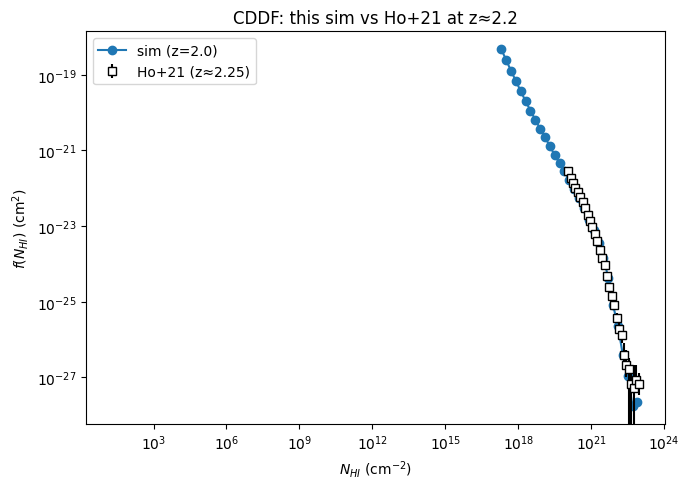

In [6]:
HO21 = Path('/home/mfho/DLA_data/ho21/cddf_z225.txt')
fig, ax = plt.subplots(figsize=(7, 5))

# Sim curve from cache
ax.loglog(10**log_nhi_centres[mask], f_nhi[mask], 'o-', label=f'sim (z={meta["z"]})')

# Ho+21
if HO21.exists():
    # File is row-major: row 0 = log NHI centres, row 1 = f central,
    # row 2 = lo68, row 3 = hi68.  Drop bins where central value is 0.
    ho21 = np.loadtxt(HO21)
    logN, fcen, flo, fhi = ho21[0], ho21[1], ho21[2], ho21[3]
    ok = np.isfinite(fcen) & (fcen > 0)
    logN, fcen, flo, fhi = logN[ok], fcen[ok], flo[ok], fhi[ok]
    yerr_lo = np.clip(fcen - flo, 0, fcen * 0.999)
    yerr_hi = np.clip(fhi - fcen, 0, None)
    ax.errorbar(10**logN, fcen, yerr=[yerr_lo, yerr_hi],
                fmt='ks', mfc='white', label='Ho+21 (z≈2.25)')
else:
    print('Ho+21 reference file not found at', HO21, '— skipping overlay.')

ax.set(xlabel=r'$N_{HI}$ (cm$^{-2}$)', ylabel=r'$f(N_{HI})$ (cm$^2$)',
       title=f'CDDF: this sim vs Ho+21 at z≈2.2')
ax.legend()
fig.tight_layout()
plt.show()


## Suggested student exercises

1. **Different (sim, snap).**  Repeat the recomputation for a different
   simulation and a different snapshot.  Pick something at z = 3 (snap
   017) or z = 4 (snap 010) and overplot Ho+21 at the matching redshift
   (`cddf_z34.txt`, `cddf_z45.txt`).
2. **Stack across sims.**  Load `cddf_corrected.npz` for all 60 LF sims
   at one snap and compute the median CDDF and its 16/84-percentile
   spread.  This is the within-LHS scatter at fixed redshift; visualise it.
3. **dN/dX(z).**  For one sim, plot dN/dX (DLA) as a function of redshift
   (snaps 4 → 23).  Compare against PRIYA papers (Bird et al. 2017).

These exercises are good warm-ups for the emulator work, where the
inputs *are* CDDFs and dN/dX values across the whole (sim, snap)
ensemble.
